#1. Import Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#2. Upload File CSV

In [4]:
file = "Fire Archive Indonesia 2019-2023.csv"

raw = pd.read_csv(file)

print("Jumlah baris :", raw.shape[0])
print("Jumlah kolom :", raw.shape[1])
raw.head()

Jumlah baris : 188506
Jumlah kolom : 15


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-4.0591,135.7771,305.3,1.0,1.0,2019-01-01,119,Terra,MODIS,42,6.03,287.5,5.0,D,0
1,-4.0605,135.7863,326.1,1.0,1.0,2019-01-01,119,Terra,MODIS,83,6.03,287.2,24.1,D,0
2,-4.0530,136.6032,313.3,1.0,1.0,2019-01-01,119,Terra,MODIS,72,6.03,292.2,9.1,D,0
3,2.7885,125.4074,313.8,1.2,1.1,2019-01-02,201,Terra,MODIS,59,6.03,282.7,12.3,D,1
4,2.7788,125.4072,329.2,1.2,1.1,2019-01-02,201,Terra,MODIS,82,6.03,284.5,30.8,D,1


#3. Cek Kondisi Data

In [ ]:
raw.info()

print("\nJumlah missing value per kolom:")
print(raw.isna().sum())

print("\nJumlah baris duplikat:", raw.duplicated().sum())
print("Rentang tanggal       :", raw["acq_date"].min(), "s.d.", raw["acq_date"].max())

print("\nJumlah titik berdasarkan type:")
print(raw["type"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188506 entries, 0 to 188505
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    188506 non-null  float64
 1   longitude   188506 non-null  float64
 2   brightness  188506 non-null  float64
 3   scan        188506 non-null  float64
 4   track       188506 non-null  float64
 5   acq_date    188506 non-null  object 
 6   acq_time    188506 non-null  int64  
 7   satellite   188506 non-null  object 
 8   instrument  188506 non-null  object 
 9   confidence  188506 non-null  int64  
 10  version     188506 non-null  float64
 11  bright_t31  188506 non-null  float64
 12  frp         188506 non-null  float64
 13  daynight    188506 non-null  object 
 14  type        188506 non-null  int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 21.6+ MB

Jumlah missing value per kolom:
latitude      0
longitude     0
brightness    0
scan          0
track         0

#4. Menyaring Wilayah Provinsi Riau

In [9]:
!pip install -q geopandas
!wget -q https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_1.json.zip
!unzip -o -q gadm41_IDN_1.json.zip

In [10]:
import geopandas as gpd

# Mengubah format acq_date menjadi tanggal
df = raw.copy()
df["acq_date"] = pd.to_datetime(df["acq_date"])

# Batas Provinsi Riau
provinsi = gpd.read_file("gadm41_IDN_1.json")[["NAME_1", "geometry"]]
provinsi = provinsi.rename(columns={"NAME_1": "provinsi"})

LAT_MIN, LAT_MAX = -1.15, 2.95
LON_MIN, LON_MAX = 100.0, 103.85
kotak = df[
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
]

# Mengubah titik panas menjadi data spasial
titik = gpd.GeoDataFrame(
    kotak,
    geometry=gpd.points_from_xy(kotak["longitude"], kotak["latitude"]),
    crs="EPSG:4326"
)

# Saringan halus: cek titik jatuh di provinsi mana (point-in-polygon)
titik = gpd.sjoin(titik, provinsi, how="left", predicate="intersects").drop(columns="index_right")
titik = titik[~titik.index.duplicated(keep="first")]   # titik tepat di garis batas

# Titik di pesisir yang sedikit meleset ke laut -> pakai provinsi terdekat (maks. 2 km)
UTM = "EPSG:32647"
lepas = titik["provinsi"].isna()
if lepas.any():
    dekat = gpd.sjoin_nearest(
        titik.loc[lepas, ["geometry"]].to_crs(UTM),
        provinsi.to_crs(UTM),
        how="left", max_distance=2000
    )
    dekat = dekat[~dekat.index.duplicated(keep="first")]
    titik.loc[lepas, "provinsi"] = dekat["provinsi"]

# Melihat ke mana saja titik-titik di dalam kotak sebenarnya berada
print("Sebaran titik di dalam kotak berdasarkan provinsi:")
print(titik["provinsi"].value_counts(dropna=False))

# Hanya ambil Provinsi Riau, kembali menjadi DataFrame biasa
wilayah = pd.DataFrame(titik[titik["provinsi"] == "Riau"].drop(columns=["geometry", "provinsi"]))

print("\nJumlah titik seluruh Indonesia :", len(df))
print("Jumlah titik di dalam kotak    :", len(kotak))
print("Jumlah titik di Provinsi Riau  :", len(wilayah))
print("\nJumlah titik di Riau berdasarkan type:")
print(wilayah["type"].value_counts())

Sebaran titik di dalam kotak berdasarkan provinsi:
provinsi
Riau             14799
Jambi              757
SumateraBarat      502
SumateraUtara      161
KepulauanRiau      102
Name: count, dtype: int64

Jumlah titik seluruh Indonesia : 188506
Jumlah titik di dalam kotak    : 16321
Jumlah titik di Provinsi Riau  : 14799

Jumlah titik di Riau berdasarkan type:
type
0    14574
2      221
3        4
Name: count, dtype: int64


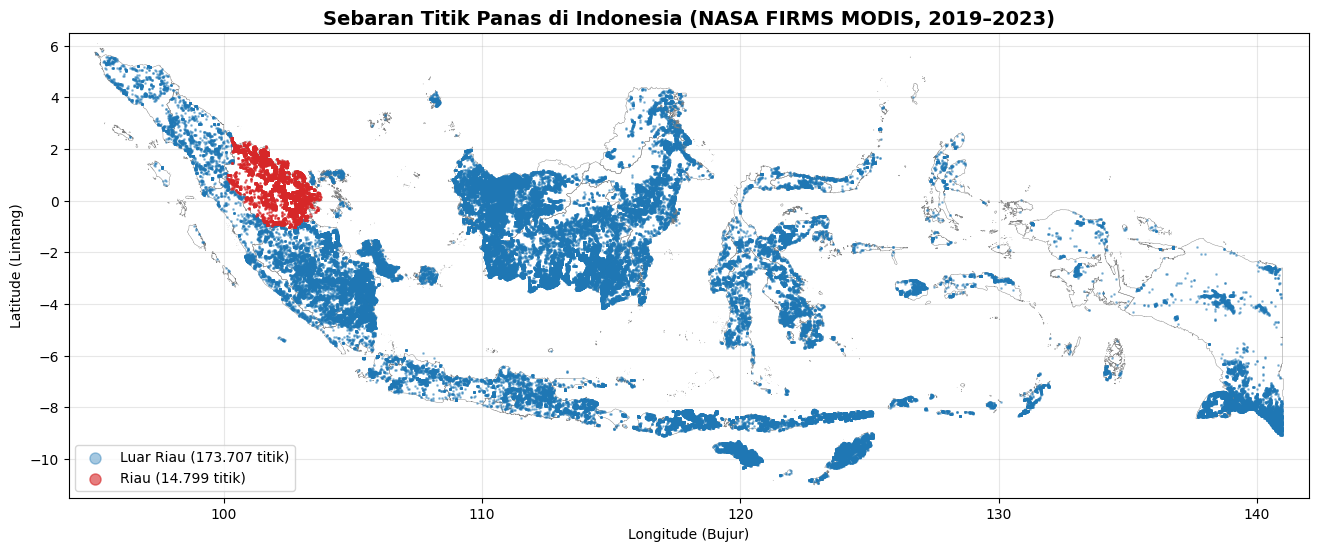

In [13]:
# Menandai titik yang termasuk Provinsi Riau (hasil penyaringan Tahap 4)
mask_riau = df.index.isin(wilayah.index)
titik_riau = df[mask_riau]
titik_luar = df[~mask_riau]

fig, ax = plt.subplots(figsize=(16, 7))

# Garis batas provinsi sebagai latar (opsional, dari data GADM di Tahap 4)
provinsi.boundary.plot(ax=ax, color="gray", linewidth=0.3, zorder=1)

# Titik di luar Riau digambar dulu, lalu titik Riau di atasnya agar terlihat jelas
ax.scatter(titik_luar["longitude"], titik_luar["latitude"],
           s=1, color="#1f77b4", alpha=0.4, zorder=2,
           label=f"Luar Riau ({len(titik_luar):,} titik)".replace(",", "."))
ax.scatter(titik_riau["longitude"], titik_riau["latitude"],
           s=1, color="#d62728", alpha=0.6, zorder=3,
           label=f"Riau ({len(titik_riau):,} titik)".replace(",", "."))

# Batas tampilan seluruh Indonesia
ax.set_xlim(94, 142)
ax.set_ylim(-11.5, 6.5)
ax.set_aspect("equal")

ax.set_xlabel("Longitude (Bujur)")
ax.set_ylabel("Latitude (Lintang)")
ax.set_title("Sebaran Titik Panas di Indonesia (NASA FIRMS MODIS, 2019–2023)",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower left", markerscale=8)
ax.grid(alpha=0.3)
plt.show()

#5. Membuat Data Clean untuk daerah Riau

In [14]:
# Batas confidence (0 = tidak ada penyaringan confidence)
BATAS_CONFIDENCE = 0

# Ambil hanya kebakaran vegetasi (type = 0)
riau = wilayah[
    (wilayah["type"] == 0) &
    (wilayah["confidence"] >= BATAS_CONFIDENCE)
].copy()

# Mengurutkan berdasarkan tanggal dan jam
riau = riau.sort_values(["acq_date", "acq_time"]).reset_index(drop=True)

# Pemeriksaan ulang data clean
print("Jumlah titik di wilayah Riau (semua type):", len(wilayah))
print("Jumlah titik yang dibuang (type 1, 2, 3)  :", len(wilayah) - len(riau))
print("Jumlah baris data clean Riau             :", len(riau))
print("\nMissing value total :", riau.isna().sum().sum())
print("Baris duplikat      :", riau.duplicated().sum())
print("Nilai type tersisa  :", riau["type"].unique())
print("Jumlah FRP = 0      :", (riau["frp"] == 0).sum())

riau["frp"] = riau["frp"].replace(0, np.nan)

print("Jumlah FRP yang menjadi missing value:", riau["frp"].isna().sum())
print("Jumlah FRP yang valid                :", riau["frp"].notna().sum())

riau.head()

Jumlah titik di wilayah Riau (semua type): 14799
Jumlah titik yang dibuang (type 1, 2, 3)  : 225
Jumlah baris data clean Riau             : 14574

Missing value total : 0
Baris duplikat      : 0
Nilai type tersisa  : [0]
Jumlah FRP = 0      : 2
Jumlah FRP yang menjadi missing value: 2
Jumlah FRP yang valid                : 14572


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-0.1680,101.7886,314.9,1.2,1.1,2019-01-02,637,Aqua,MODIS,52,6.03,296.5,9.1,D,0
1,-0.1695,101.7776,318.1,1.2,1.1,2019-01-02,637,Aqua,MODIS,71,6.03,296.5,12.7,D,0
2,1.6180,101.2628,302.3,1.6,1.3,2019-01-02,1602,Terra,MODIS,48,6.03,274.6,11.7,N,0
3,1.6292,101.2611,312.4,1.6,1.3,2019-01-02,1602,Terra,MODIS,85,6.03,274.4,25.4,N,0
4,1.6312,101.2756,305.0,1.6,1.3,2019-01-02,1602,Terra,MODIS,63,6.03,274.6,15.2,N,0


#6. Membuat variabel turunan tahun, bulan, dan musim

In [15]:
# List bulan kemarau di Riau berdasarkan BMKG
BULAN_KEMARAU = [2, 3, 6, 7, 8, 9]

# Membuat kolom tahun, bulan, dan musim
riau["tahun"] = riau["acq_date"].dt.year
riau["bulan"] = riau["acq_date"].dt.month
riau["musim"] = np.where(riau["bulan"].isin(BULAN_KEMARAU), "Kemarau", "Hujan")

# Menyusun ulang urutan kolom
urutan_kolom = ["latitude", "longitude", "brightness", "scan", "track", "acq_date",
                "tahun", "bulan", "musim", "acq_time", "satellite", "instrument",
                "confidence", "version", "bright_t31", "frp", "daynight", "type"]
riau = riau[urutan_kolom]

# Mengecek hasil
print("Jumlah titik per musim:")
print(riau["musim"].value_counts())
print("\nJumlah titik per tahun:")
print(riau["tahun"].value_counts().sort_index())
print("\nJumlah kolom sekarang:", riau.shape[1])

riau.head()

Jumlah titik per musim:
musim
Kemarau    11471
Hujan       3103
Name: count, dtype: int64

Jumlah titik per tahun:
tahun
2019    8720
2020    2031
2021    1646
2022     789
2023    1388
Name: count, dtype: int64

Jumlah kolom sekarang: 18


,latitude,longitude,brightness,scan,track,acq_date,tahun,bulan,musim,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-0.1680,101.7886,314.9,1.2,1.1,2019-01-02,2019,1,Hujan,637,Aqua,MODIS,52,6.03,296.5,9.1,D,0
1,-0.1695,101.7776,318.1,1.2,1.1,2019-01-02,2019,1,Hujan,637,Aqua,MODIS,71,6.03,296.5,12.7,D,0
2,1.6180,101.2628,302.3,1.6,1.3,2019-01-02,2019,1,Hujan,1602,Terra,MODIS,48,6.03,274.6,11.7,N,0
3,1.6292,101.2611,312.4,1.6,1.3,2019-01-02,2019,1,Hujan,1602,Terra,MODIS,85,6.03,274.4,25.4,N,0
4,1.6312,101.2756,305.0,1.6,1.3,2019-01-02,2019,1,Hujan,1602,Terra,MODIS,63,6.03,274.6,15.2,N,0


#7. Membuat variabel jumlah_hotspot_harian

In [16]:
# Membuat daftar semua tanggal dari awal sampai akhir periode
semua_hari = pd.date_range(df["acq_date"].min(), df["acq_date"].max(), freq="D")

# Menghitung jumlah titik panas per hari
harian = (
    riau.groupby("acq_date").size()
        .reindex(semua_hari, fill_value=0)
        .rename("jumlah_hotspot_harian")
        .rename_axis("tanggal")
        .reset_index()
)

# Menambahkan tahun, bulan, dan musim
harian["tahun"] = harian["tanggal"].dt.year
harian["bulan"] = harian["tanggal"].dt.month
harian["musim"] = np.where(harian["bulan"].isin(BULAN_KEMARAU), "Kemarau", "Hujan")
harian = harian[["tanggal", "tahun", "bulan", "musim", "jumlah_hotspot_harian"]]

# Mengecek hasil
print("Jumlah hari                    :", len(harian))
print("Total titik panas              :", harian["jumlah_hotspot_harian"].sum())
print("Total titik di data clean      :", len(riau))
print("Hari tanpa titik panas         :", (harian["jumlah_hotspot_harian"] == 0).sum())
print("Jumlah titik terbanyak per hari:", harian["jumlah_hotspot_harian"].max())
print("Tanggal dengan titik terbanyak :", harian.loc[harian["jumlah_hotspot_harian"].idxmax(), "tanggal"].date())
print("\nJumlah hari per musim:")
print(harian["musim"].value_counts())

harian.head()

Jumlah hari                    : 1826
Total titik panas              : 14574
Total titik di data clean      : 14574
Hari tanpa titik panas         : 860
Jumlah titik terbanyak per hari: 325
Tanggal dengan titik terbanyak : 2019-08-23

Jumlah hari per musim:
musim
Hujan      920
Kemarau    906
Name: count, dtype: int64


,tanggal,tahun,bulan,musim,jumlah_hotspot_harian
0,2019-01-01,2019,1,Hujan,0
1,2019-01-02,2019,1,Hujan,9
2,2019-01-03,2019,1,Hujan,5
3,2019-01-04,2019,1,Hujan,6
4,2019-01-05,2019,1,Hujan,7


#8. Statistika Deskriptif

In [17]:
def statistik_deskriptif(data):
    data = data.dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    return pd.Series({
        "Jumlah data (n)": len(data),
        "Rata-rata (mean)": data.mean(),
        "Median": data.median(),
        "Modus": data.mode().iloc[0],
        "Standar deviasi": data.std(),
        "Varians": data.var(),
        "Minimum": data.min(),
        "Kuartil 1 (Q1)": q1,
        "Kuartil 3 (Q3)": q3,
        "Maksimum": data.max(),
        "Jangkauan (range)": data.max() - data.min(),
        "IQR (Q3 - Q1)": q3 - q1,
        "Koefisien variasi (%)": data.std() / data.mean() * 100,
        "Skewness": data.skew(),
        "Kurtosis": data.kurt(),
    })

pd.set_option("display.float_format", "{:.2f}".format)

tabel_deskriptif = pd.DataFrame({
    "FRP (MW)": statistik_deskriptif(riau["frp"]),
    "Brightness (K)": statistik_deskriptif(riau["brightness"]),
    "Jumlah hotspot harian": statistik_deskriptif(harian["jumlah_hotspot_harian"]),
})
tabel_deskriptif

,FRP (MW),Brightness (K),Jumlah hotspot harian
Jumlah data (n),14572.00,14574.00,1826.00
Rata-rata (mean),27.49,318.61,7.98
Median,15.60,316.00,1.00
Modus,10.40,316.50,0.00
Standar deviasi,44.63,13.30,25.41
Varians,1992.01,176.85,645.72
Minimum,2.50,300.00,0.00
Kuartil 1 (Q1),9.50,310.80,0.00
Kuartil 3 (Q3),29.10,322.60,6.00
Maksimum,1366.10,457.20,325.00


In [18]:
# Statistik deskriptif per musim dan per tahun

print("=== FRP per musim ===")
print(riau.groupby("musim")["frp"].agg(["count", "mean", "median", "std", "min", "max"]))

print("\n=== FRP per tahun ===")
print(riau.groupby("tahun")["frp"].agg(["count", "mean", "median", "std", "min", "max"]))

print("\n=== Jumlah hotspot harian per musim ===")
print(harian.groupby("musim")["jumlah_hotspot_harian"].agg(["count", "sum", "mean", "median", "std", "max"]))

print("\n=== Jumlah hotspot harian per tahun ===")
print(harian.groupby("tahun")["jumlah_hotspot_harian"].agg(["count", "sum", "mean", "median", "std", "max"]))

=== FRP per musim ===
         count  mean  median   std  min     max
musim                                          
Hujan     3103 17.65   13.00 16.85 3.20  263.70
Kemarau  11469 30.15   16.70 49.20 2.50 1366.10

=== FRP per tahun ===
       count  mean  median   std  min     max
tahun                                        
2019    8718 31.61   17.40 51.52 2.50 1366.10
2020    2031 23.42   15.40 28.22 2.80  328.60
2021    1646 22.09   13.70 30.56 3.30  537.10
2022     789 16.69   12.70 14.93 3.20  211.50
2023    1388 20.07   12.60 39.44 2.60 1156.60

=== Jumlah hotspot harian per musim ===
         count    sum  mean  median   std  max
musim                                         
Hujan      920   3103  3.37    0.00  6.78   60
Kemarau    906  11471 12.66    2.00 34.81  325

=== Jumlah hotspot harian per tahun ===
       count   sum  mean  median   std  max
tahun                                      
2019     365  8720 23.89    4.00 51.01  325
2020     366  2031  5.55    1.00 12.96 

#9. Visualisasi Data

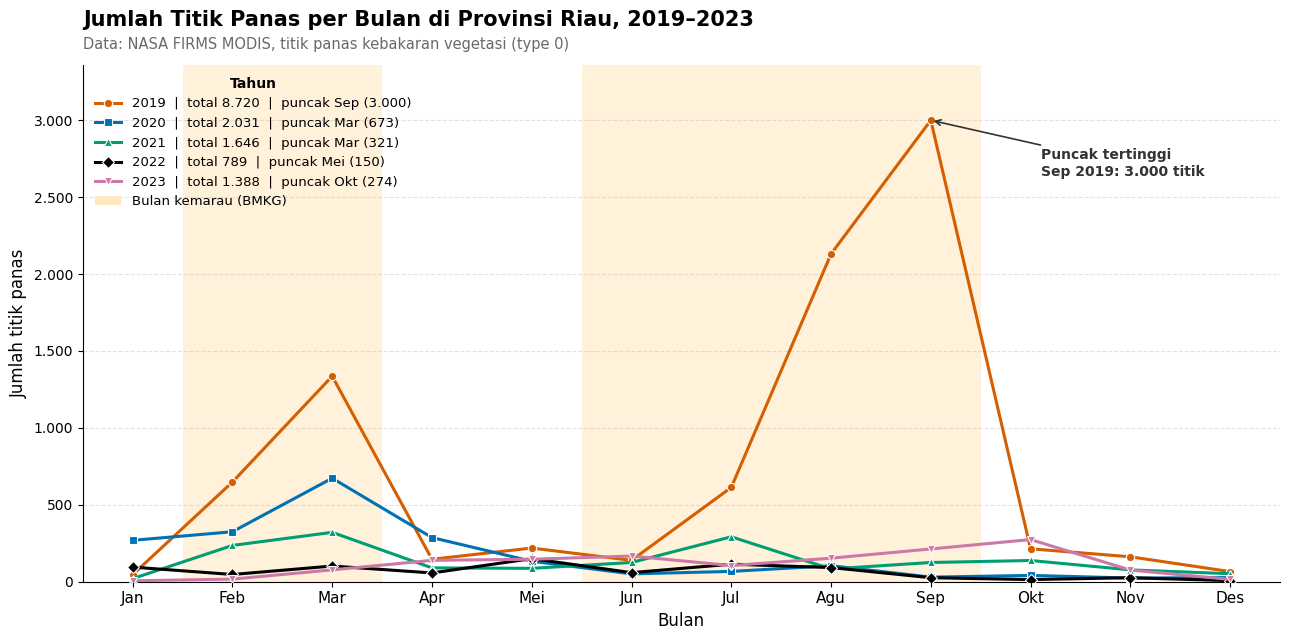

tahun,2019,2020,2021,2022,2023
bulan,,,,,
1,46,269,20,95,6
2,648,325,236,47,17
3,1336,673,321,102,77
4,146,287,90,57,139
5,219,133,87,150,146
6,139,51,125,59,167
7,613,67,292,114,105
8,2131,104,83,92,153
9,3000,30,125,26,213


In [34]:
# Line Chart jumlah titik panas per bulan
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

nama_bulan = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

pola_bulanan = harian.pivot_table(index="bulan", columns="tahun",
                                  values="jumlah_hotspot_harian", aggfunc="sum")

# Warna ramah buta warna (Okabe-Ito) dan bentuk penanda berbeda tiap tahun
WARNA_TAHUN = ["#D55E00", "#0072B2", "#009E73", "#000000", "#CC79A7"]
MARKER_TAHUN = ["o", "s", "^", "D", "v"]

def format_ribuan(angka):
    return f"{angka:,.0f}".replace(",", ".")

fig, ax = plt.subplots(figsize=(13, 6.5))

# Latar belakang bulan kemarau (BMKG)
for bulan in BULAN_KEMARAU:
    ax.axvspan(bulan - 0.5, bulan + 0.5, color="#FFE8C2", alpha=0.6, linewidth=0, zorder=0)

# Satu garis per tahun, keterangan legenda berisi total dan bulan puncak
for warna, marker, tahun in zip(WARNA_TAHUN, MARKER_TAHUN, pola_bulanan.columns):
    nilai = pola_bulanan[tahun]
    bulan_puncak = nilai.idxmax()
    keterangan = (f"{tahun}  |  total {format_ribuan(nilai.sum())}  |  "
                  f"puncak {nama_bulan[bulan_puncak - 1]} ({format_ribuan(nilai.max())})")
    ax.plot(pola_bulanan.index, nilai, color=warna, marker=marker, linewidth=2.2,
            markersize=6, markeredgecolor="white", markeredgewidth=0.8, label=keterangan, zorder=3)

# Anotasi puncak tertinggi selama periode pengamatan
tahun_maks = pola_bulanan.max().idxmax()
bulan_maks = pola_bulanan[tahun_maks].idxmax()
nilai_maks = pola_bulanan.loc[bulan_maks, tahun_maks]
ax.annotate(f"Puncak tertinggi\n{nama_bulan[bulan_maks - 1]} {tahun_maks}: {format_ribuan(nilai_maks)} titik",
            xy=(bulan_maks, nilai_maks), xytext=(bulan_maks + 1.1, nilai_maks * 0.88),
            fontsize=10, fontweight="bold", color="#333333",
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1.2))

# Pengaturan sumbu
ax.set_xticks(pola_bulanan.index)
ax.set_xticklabels(nama_bulan, fontsize=11)
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, nilai_maks * 1.12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: format_ribuan(v)))
ax.set_xlabel("Bulan", fontsize=12)
ax.set_ylabel("Jumlah titik panas", fontsize=12)
ax.grid(axis="y", alpha=0.35, linestyle="--")
for sisi in ["top", "right"]:
    ax.spines[sisi].set_visible(False)

# Judul, legenda, dan sumber data
ax.set_title("Jumlah Titik Panas per Bulan di Provinsi Riau, 2019–2023",
             fontsize=15, fontweight="bold", loc="left", pad=28)
ax.text(0, 1.03, "Data: NASA FIRMS MODIS, titik panas kebakaran vegetasi (type 0)",
        transform=ax.transAxes, fontsize=10.5, color="dimgray")
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="#FFE8C2", label="Bulan kemarau (BMKG)"))
ax.legend(handles=handles, loc="upper left", fontsize=9.5, frameon=False, title="Tahun",
          title_fontproperties={"weight": "bold"})

plt.tight_layout()
plt.show()

pola_bulanan

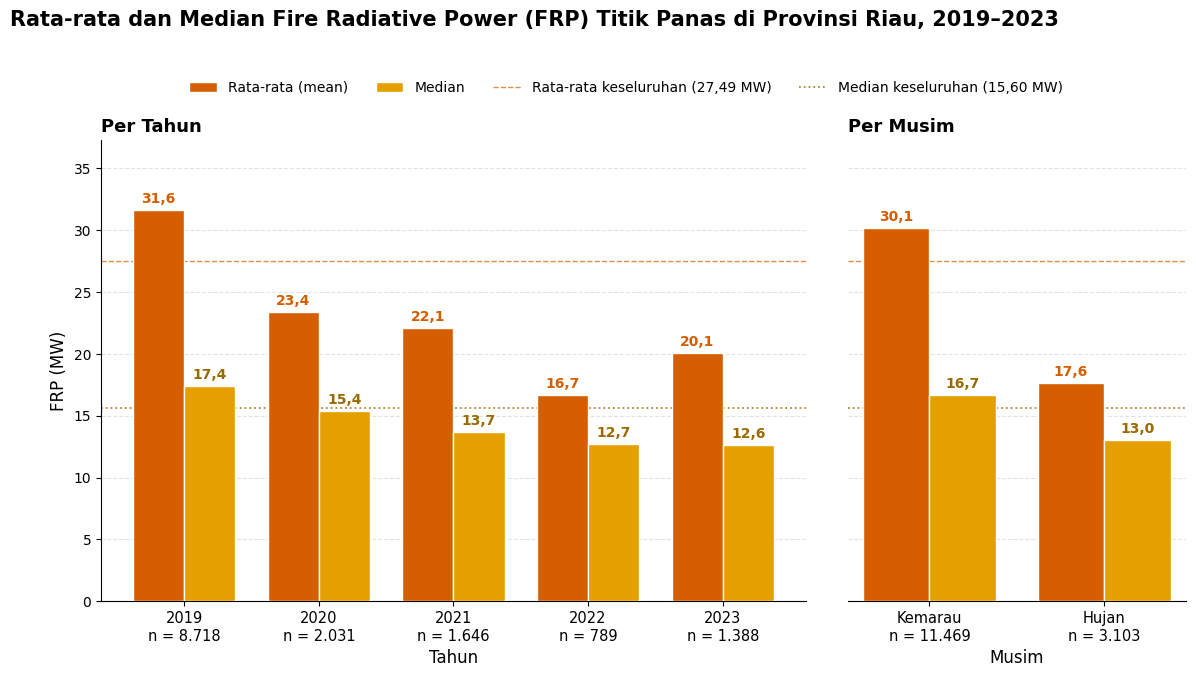

In [37]:
# Bar Chart mean dan median FRP
frp_tahun = riau.groupby("tahun")["frp"].agg(["mean", "median"])
frp_musim = riau.groupby("musim")["frp"].agg(["mean", "median"]).reindex(["Kemarau", "Hujan"])

# Informasi pendukung: jumlah titik ber-FRP valid dan nilai keseluruhan
n_tahun = riau.groupby("tahun")["frp"].count()
n_musim = riau.groupby("musim")["frp"].count().reindex(["Kemarau", "Hujan"])
mean_all, median_all = riau["frp"].mean(), riau["frp"].median()

WARNA_MEAN, WARNA_MEDIAN = "#D55E00", "#E69F00"

def koma(angka, desimal=1):
    return f"{angka:.{desimal}f}".replace(".", ",")

def ribuan(angka):
    return f"{angka:,.0f}".replace(",", ".")

fig, ax = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True,
                       gridspec_kw={"width_ratios": [5, 2.4], "wspace": 0.08})
lebar = 0.38
batas_atas = max(frp_tahun["mean"].max(), frp_musim["mean"].max()) * 1.18

for a, data, n, judul, xlabel in [
    (ax[0], frp_tahun, n_tahun, "Per Tahun", "Tahun"),
    (ax[1], frp_musim, n_musim, "Per Musim", "Musim"),
]:
    x = np.arange(len(data))
    b1 = a.bar(x - lebar/2, data["mean"], lebar, label="Rata-rata (mean)",
               color=WARNA_MEAN, edgecolor="white", zorder=3)
    b2 = a.bar(x + lebar/2, data["median"], lebar, label="Median",
               color=WARNA_MEDIAN, edgecolor="white", zorder=3)
    a.bar_label(b1, labels=[koma(v) for v in data["mean"]], padding=3,
                fontsize=10, fontweight="bold", color=WARNA_MEAN)
    a.bar_label(b2, labels=[koma(v) for v in data["median"]], padding=3,
                fontsize=10, fontweight="bold", color="#9A6A00")

    # Garis acuan nilai keseluruhan 2019–2023
    a.axhline(mean_all, color=WARNA_MEAN, linestyle="--", linewidth=1, alpha=0.7, zorder=2,
              label=f"Rata-rata keseluruhan ({koma(mean_all, 2)} MW)")
    a.axhline(median_all, color="#9A6A00", linestyle=":", linewidth=1.3, alpha=0.8, zorder=2,
              label=f"Median keseluruhan ({koma(median_all, 2)} MW)")

    # Label sumbu X dilengkapi jumlah titik (n)
    a.set_xticks(x)
    a.set_xticklabels([f"{k}\nn = {ribuan(v)}" for k, v in zip(data.index, n)], fontsize=10.5)
    a.set_title(judul, fontsize=13, fontweight="bold", loc="left")
    a.set_xlabel(xlabel, fontsize=12)
    a.set_ylim(0, batas_atas)
    a.grid(axis="y", alpha=0.35, linestyle="--", zorder=0)
    for sisi in ["top", "right"]:
        a.spines[sisi].set_visible(False)

ax[1].spines["left"].set_visible(False)
ax[1].tick_params(axis="y", length=0)
ax[0].set_ylabel("FRP (MW)", fontsize=12)

# Judul, subjudul, legenda bersama, dan catatan interpretasi
fig.suptitle("Rata-rata dan Median Fire Radiative Power (FRP) Titik Panas di Provinsi Riau, 2019–2023",
             fontsize=15, fontweight="bold", x=0.06, ha="left", y=1.02)
handles, labels = ax[0].get_legend_handles_labels()
urutan = [2, 3, 0, 1]
handles, labels = [handles[i] for i in urutan], [labels[i] for i in urutan]
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.93))

fig.subplots_adjust(top=0.82)
plt.show()

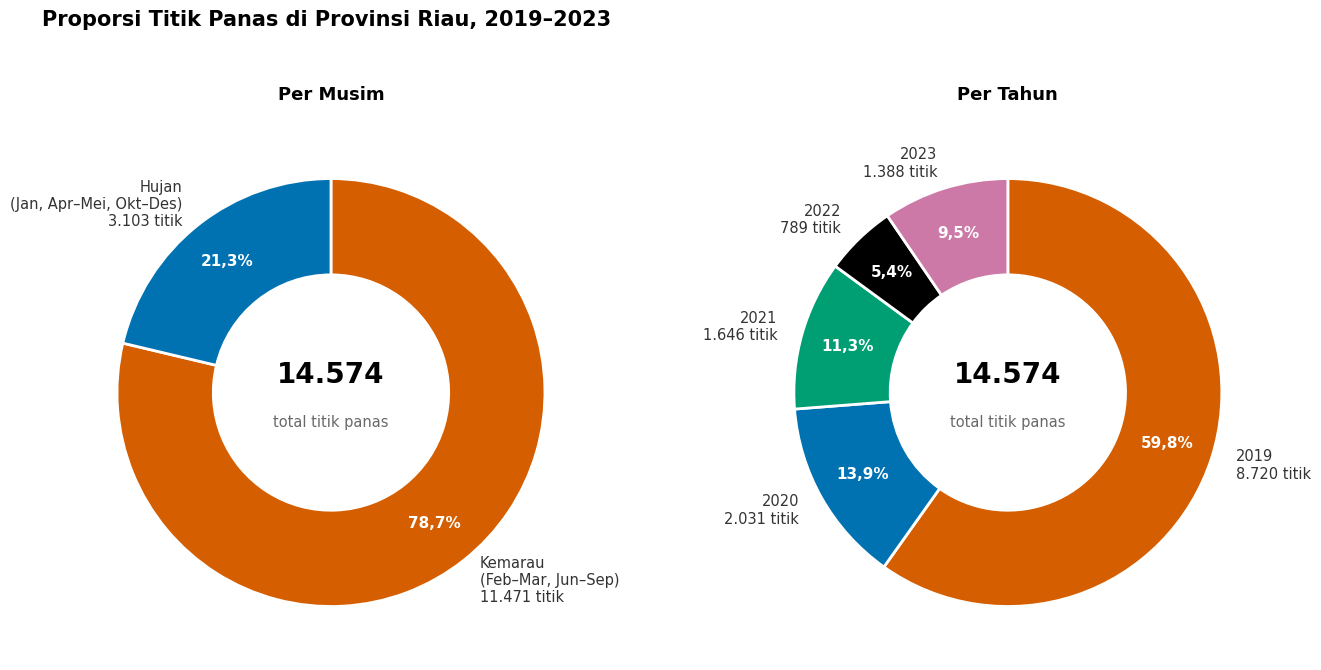

In [42]:
# Pie Chart proporsi titik panas
titik_musim = riau["musim"].value_counts().reindex(["Kemarau", "Hujan"])
titik_tahun = riau["tahun"].value_counts().sort_index()

WARNA_MUSIM = ["#D55E00", "#0072B2"]                                  # Kemarau, Hujan
WARNA_TAHUN = ["#D55E00", "#0072B2", "#009E73", "#000000", "#CC79A7"]  # sama dengan Line Chart

def ribuan(angka):
    return f"{angka:,.0f}".replace(",", ".")

def persen(p):
    return f"{p:.1f}%".replace(".", ",")

keterangan_musim = {"Kemarau": "Kemarau\n(Feb–Mar, Jun–Sep)", "Hujan": "Hujan\n(Jan, Apr–Mei, Okt–Des)"}

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

for a, data, warna, judul, nama in [
    (ax[0], titik_musim, WARNA_MUSIM, "Per Musim", [keterangan_musim[m] for m in titik_musim.index]),
    (ax[1], titik_tahun, WARNA_TAHUN, "Per Tahun", [str(t) for t in titik_tahun.index]),
]:
    label_luar = [f"{n}\n{ribuan(v)} titik" for n, v in zip(nama, data)]
    _, teks, teks_persen = a.pie(
        data, labels=label_luar, colors=warna, autopct=persen,
        startangle=90, counterclock=False, pctdistance=0.78, labeldistance=1.12,
        wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 10.5}
    )
    plt.setp(teks_persen, color="white", fontweight="bold", fontsize=11)
    plt.setp(teks, color="#333333")

    # Total titik di tengah donut
    a.text(0, 0.08, ribuan(data.sum()), ha="center", va="center", fontsize=20, fontweight="bold")
    a.text(0, -0.14, "total titik panas", ha="center", va="center", fontsize=10.5, color="dimgray")
    a.set_title(judul, fontsize=13, fontweight="bold", pad=18)
    a.set_aspect("equal")

# Judul
fig.suptitle("Proporsi Titik Panas di Provinsi Riau, 2019–2023",
             fontsize=15, fontweight="bold", x=0.06, ha="left", y=1.0)

musim_dominan = titik_musim.idxmax()
tahun_dominan = titik_tahun.idxmax()

plt.tight_layout(rect=(0, 0.05, 1, 0.93))
plt.show()

#10. Dashboard Visualisasi Data

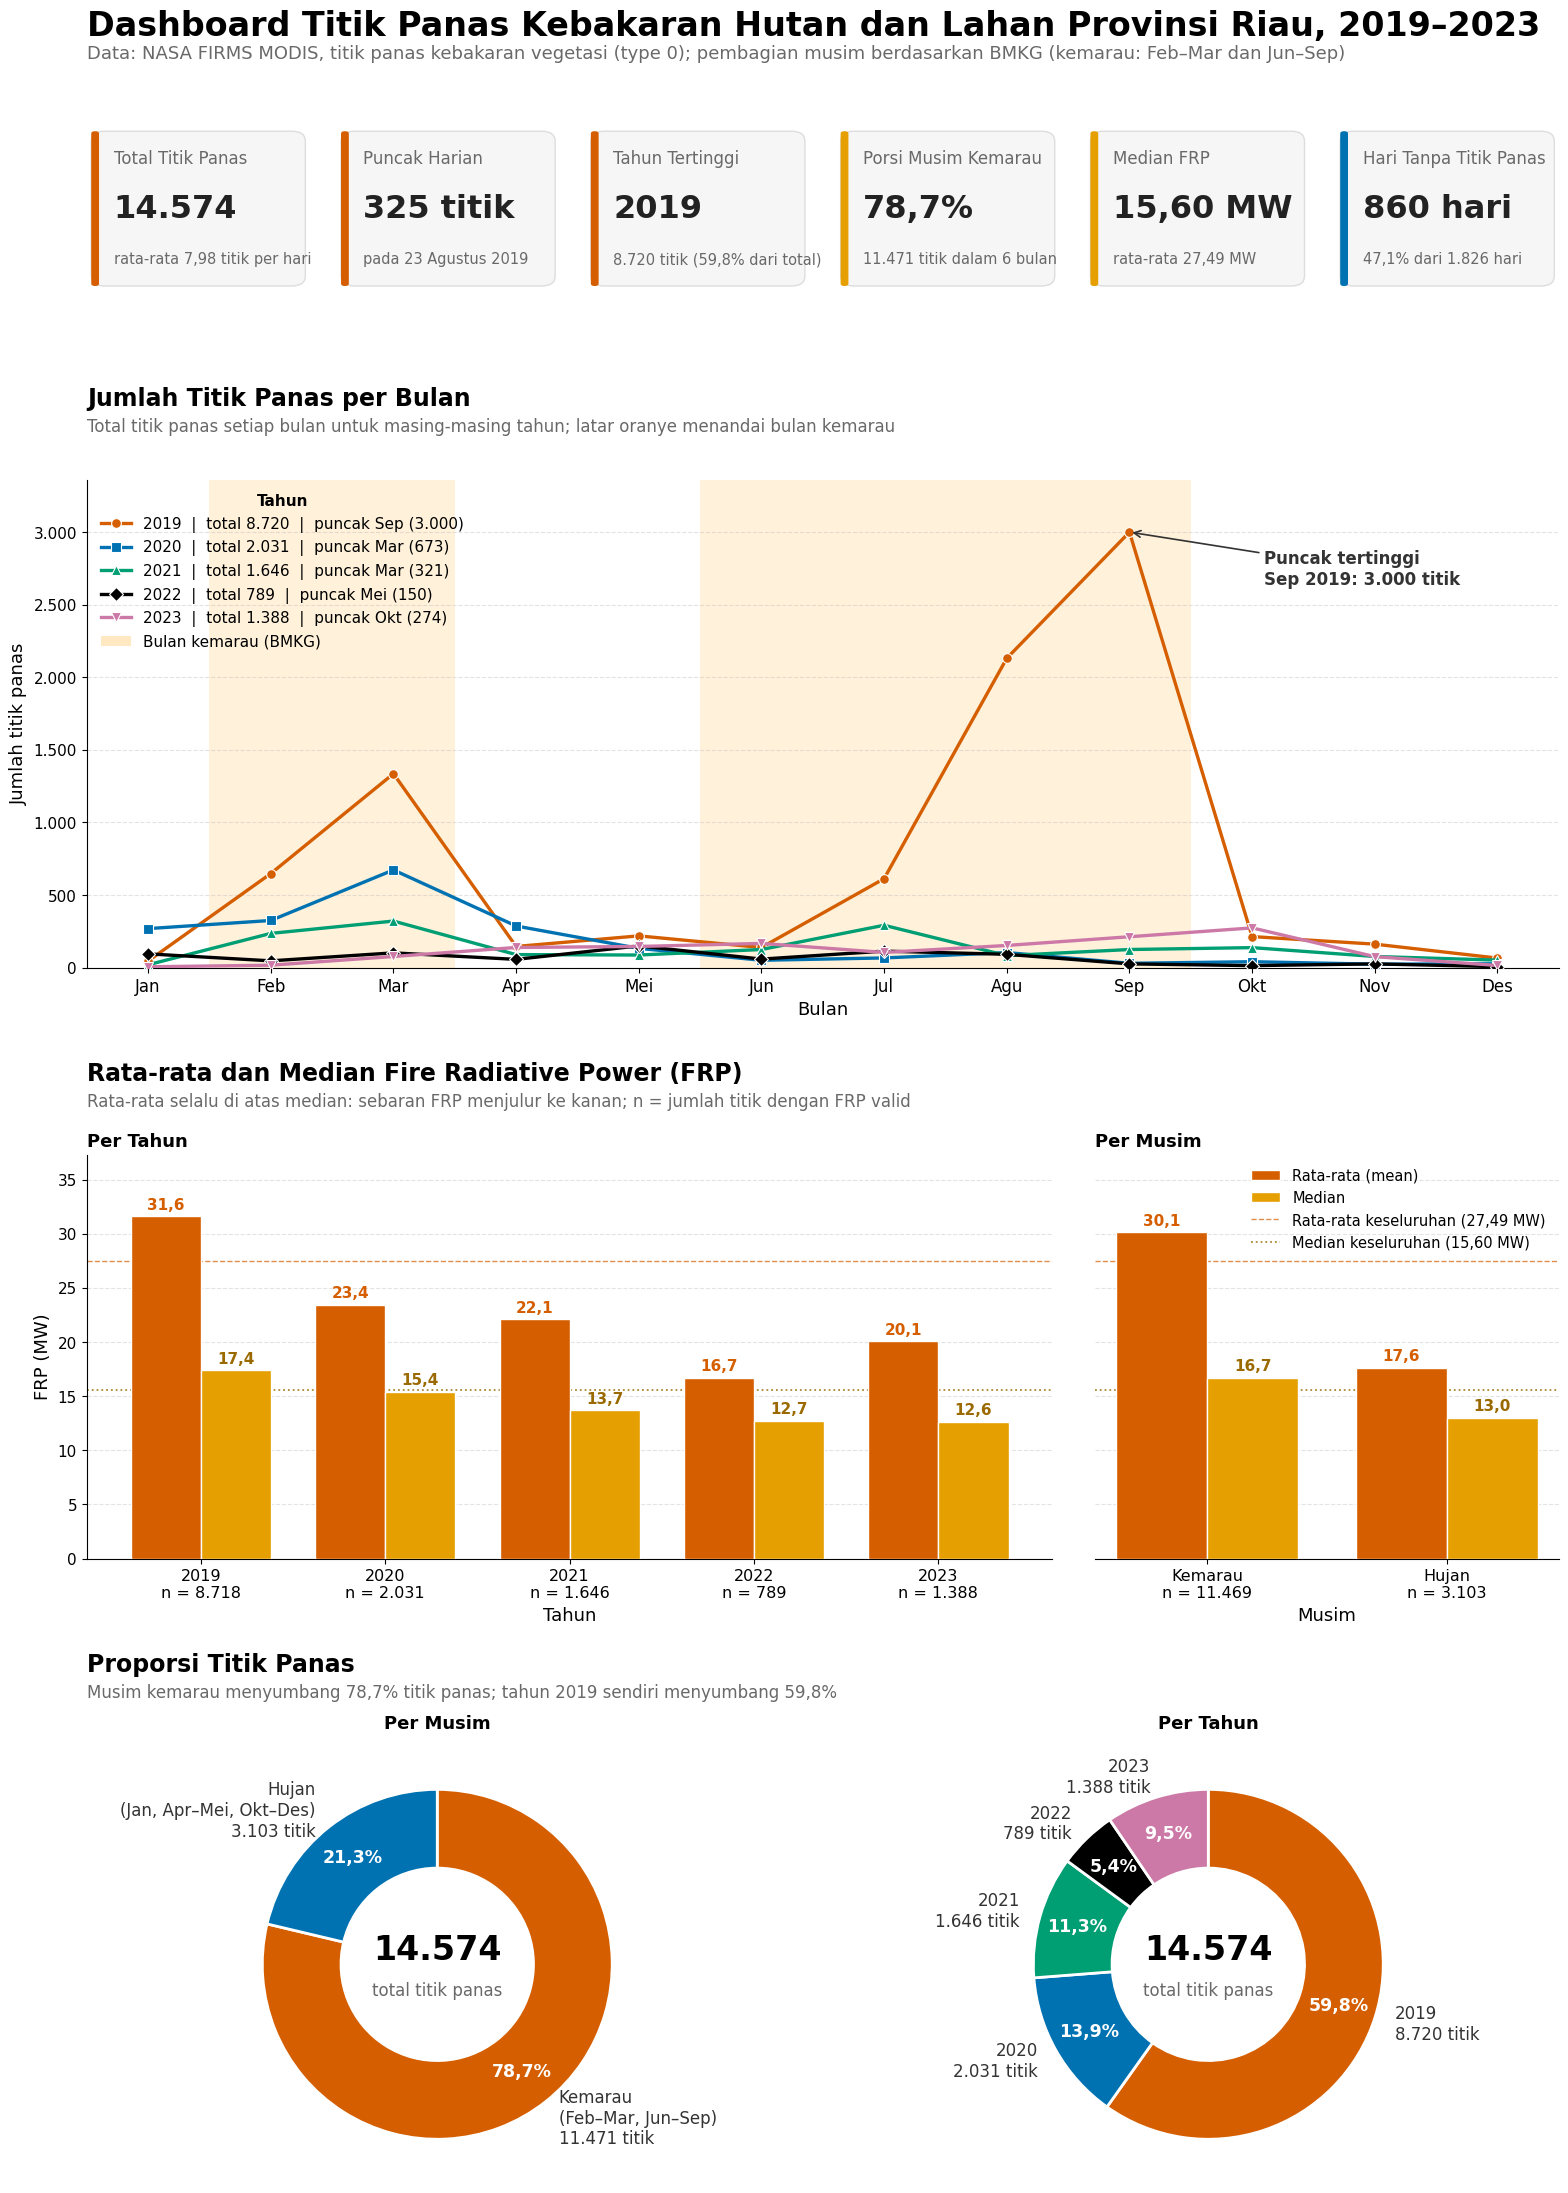

In [43]:
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.ticker import FuncFormatter

# =========================================================
# 1. Menyiapkan data (sama dengan Line, Bar, dan Pie Chart)
# =========================================================
nama_bulan = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
nama_bulan_panjang = ["Januari", "Februari", "Maret", "April", "Mei", "Juni", "Juli",
                      "Agustus", "September", "Oktober", "November", "Desember"]

pola_bulanan = harian.pivot_table(index="bulan", columns="tahun",
                                  values="jumlah_hotspot_harian", aggfunc="sum")

frp_tahun = riau.groupby("tahun")["frp"].agg(["mean", "median"])
frp_musim = riau.groupby("musim")["frp"].agg(["mean", "median"]).reindex(["Kemarau", "Hujan"])
n_tahun = riau.groupby("tahun")["frp"].count()
n_musim = riau.groupby("musim")["frp"].count().reindex(["Kemarau", "Hujan"])
mean_all, median_all = riau["frp"].mean(), riau["frp"].median()

titik_musim = riau["musim"].value_counts().reindex(["Kemarau", "Hujan"])
titik_tahun = riau["tahun"].value_counts().sort_index()

# Angka untuk kartu ringkasan
total_titik = len(riau)
jumlah_hari = len(harian)
rata_harian = harian["jumlah_hotspot_harian"].mean()
hari_tanpa = (harian["jumlah_hotspot_harian"] == 0).sum()
idx_puncak = harian["jumlah_hotspot_harian"].idxmax()
puncak_jumlah = harian.loc[idx_puncak, "jumlah_hotspot_harian"]
tgl = harian.loc[idx_puncak, "tanggal"]
puncak_tanggal = f"{tgl.day} {nama_bulan_panjang[tgl.month - 1]} {tgl.year}"
tahun_tertinggi = titik_tahun.idxmax()
# =========================================================
# 2. Pengaturan gaya
# =========================================================
WARNA_TAHUN = ["#D55E00", "#0072B2", "#009E73", "#000000", "#CC79A7"]
MARKER_TAHUN = ["o", "s", "^", "D", "v"]
WARNA_MUSIM = ["#D55E00", "#0072B2"]
WARNA_MEAN, WARNA_MEDIAN, WARNA_MEDIAN_TEKS = "#D55E00", "#E69F00", "#9A6A00"
WARNA_KEMARAU_LATAR = "#FFE8C2"

def ribuan(angka):
    return f"{angka:,.0f}".replace(",", ".")

def koma(angka, desimal=1):
    return f"{angka:.{desimal}f}".replace(".", ",")

def persen(p):
    return f"{p:.1f}%".replace(".", ",")

def rapikan_sumbu(ax):
    for sisi in ["top", "right"]:
        ax.spines[sisi].set_visible(False)

def judul_bagian(spec, judul, subjudul):
    # Judul dan subjudul tiap baris, rata kiri sejajar dengan judul dashboard
    atas = spec.get_position(fig).y1
    fig.text(0.05, atas + 0.030, judul, fontsize=17, fontweight="bold", va="bottom")
    fig.text(0.05, atas + 0.027, subjudul, fontsize=12, color="dimgray", va="top")

# =========================================================
# 3. Kerangka dashboard
# =========================================================
fig = plt.figure(figsize=(16, 23))
grid = fig.add_gridspec(4, 1, height_ratios=[0.5, 1.45, 1.2, 1.3], hspace=0.5,
                        left=0.05, right=0.97, top=0.925, bottom=0.03)

fig.text(0.05, 0.975, "Dashboard Titik Panas Kebakaran Hutan dan Lahan Provinsi Riau, 2019–2023",
         fontsize=24, fontweight="bold", va="top")
fig.text(0.05, 0.96, "Data: NASA FIRMS MODIS, titik panas kebakaran vegetasi (type 0); "
         "pembagian musim berdasarkan BMKG (kemarau: Feb–Mar dan Jun–Sep)",
         fontsize=13, color="dimgray", va="top")

# ---------------------------------------------------------
# Baris kartu ringkasan
# ---------------------------------------------------------
kartu = [
    ("Total Titik Panas", ribuan(total_titik), f"rata-rata {koma(rata_harian, 2)} titik per hari", "#D55E00"),
    ("Puncak Harian", f"{ribuan(puncak_jumlah)} titik", f"pada {puncak_tanggal}", "#D55E00"),
    ("Tahun Tertinggi", f"{tahun_tertinggi}",
     f"{ribuan(titik_tahun.max())} titik ({persen(titik_tahun.max() / total_titik * 100)} dari total)", "#D55E00"),
    ("Porsi Musim Kemarau", persen(titik_musim["Kemarau"] / total_titik * 100),
     f"{ribuan(titik_musim['Kemarau'])} titik dalam 6 bulan", "#E69F00"),
    ("Median FRP", f"{koma(median_all, 2)} MW", f"rata-rata {koma(mean_all, 2)} MW", "#E69F00"),
    ("Hari Tanpa Titik Panas", f"{ribuan(hari_tanpa)} hari",
     f"{persen(hari_tanpa / jumlah_hari * 100)} dari {ribuan(jumlah_hari)} hari", "#0072B2"),
]
sub_kartu = grid[0].subgridspec(1, len(kartu), wspace=0.12)
for i, (judul, nilai, keterangan, aksen) in enumerate(kartu):
    ax = fig.add_subplot(sub_kartu[0, i])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(FancyBboxPatch((0.02, 0.04), 0.96, 0.92, boxstyle="round,pad=0,rounding_size=0.06",
                                facecolor="#F6F6F6", edgecolor="#DDDDDD", linewidth=1))
    ax.add_patch(FancyBboxPatch((0.02, 0.04), 0.035, 0.92, boxstyle="round,pad=0,rounding_size=0.015",
                                facecolor=aksen, edgecolor="none"))
    ax.text(0.12, 0.80, judul, fontsize=12, color="dimgray", va="center")
    ax.text(0.12, 0.50, nilai, fontsize=23, fontweight="bold", color="#222222", va="center")
    ax.text(0.12, 0.20, keterangan, fontsize=10.5, color="dimgray", va="center")

# ---------------------------------------------------------
# Baris 1: Line Chart
# ---------------------------------------------------------
ax = fig.add_subplot(grid[1])
for bulan in BULAN_KEMARAU:
    ax.axvspan(bulan - 0.5, bulan + 0.5, color=WARNA_KEMARAU_LATAR, alpha=0.6, linewidth=0, zorder=0)

for warna, marker, tahun in zip(WARNA_TAHUN, MARKER_TAHUN, pola_bulanan.columns):
    nilai = pola_bulanan[tahun]
    keterangan = (f"{tahun}  |  total {ribuan(nilai.sum())}  |  "
                  f"puncak {nama_bulan[nilai.idxmax() - 1]} ({ribuan(nilai.max())})")
    ax.plot(pola_bulanan.index, nilai, color=warna, marker=marker, linewidth=2.4, markersize=7,
            markeredgecolor="white", markeredgewidth=0.8, label=keterangan, zorder=3)

tahun_maks = pola_bulanan.max().idxmax()
bulan_maks = pola_bulanan[tahun_maks].idxmax()
nilai_maks = pola_bulanan.loc[bulan_maks, tahun_maks]
ax.annotate(f"Puncak tertinggi\n{nama_bulan[bulan_maks - 1]} {tahun_maks}: {ribuan(nilai_maks)} titik",
            xy=(bulan_maks, nilai_maks), xytext=(bulan_maks + 1.1, nilai_maks * 0.88),
            fontsize=12, fontweight="bold", color="#333333",
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1.2))

ax.set_xticks(pola_bulanan.index)
ax.set_xticklabels(nama_bulan, fontsize=12)
ax.tick_params(axis="y", labelsize=11)
ax.set_xlim(0.5, 12.5)
ax.set_ylim(0, nilai_maks * 1.12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: ribuan(v)))
ax.set_xlabel("Bulan", fontsize=13)
ax.set_ylabel("Jumlah titik panas", fontsize=13)
ax.grid(axis="y", alpha=0.35, linestyle="--")
rapikan_sumbu(ax)
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor=WARNA_KEMARAU_LATAR, label="Bulan kemarau (BMKG)"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=False,
          title="Tahun", title_fontproperties={"weight": "bold", "size": 11})
judul_bagian(grid[1], "Jumlah Titik Panas per Bulan",
             "Total titik panas setiap bulan untuk masing-masing tahun; latar oranye menandai bulan kemarau")

# ---------------------------------------------------------
# Baris 2: Bar Chart
# ---------------------------------------------------------
sub_bar = grid[2].subgridspec(1, 2, width_ratios=[5, 2.4], wspace=0.06)
ax_bar = [fig.add_subplot(sub_bar[0, 0])]
ax_bar.append(fig.add_subplot(sub_bar[0, 1], sharey=ax_bar[0]))
lebar = 0.38
batas_atas = max(frp_tahun["mean"].max(), frp_musim["mean"].max()) * 1.18

for a, data, n, judul, xlabel in [
    (ax_bar[0], frp_tahun, n_tahun, "Per Tahun", "Tahun"),
    (ax_bar[1], frp_musim, n_musim, "Per Musim", "Musim"),
]:
    x = np.arange(len(data))
    b1 = a.bar(x - lebar/2, data["mean"], lebar, label="Rata-rata (mean)",
               color=WARNA_MEAN, edgecolor="white", zorder=3)
    b2 = a.bar(x + lebar/2, data["median"], lebar, label="Median",
               color=WARNA_MEDIAN, edgecolor="white", zorder=3)
    a.bar_label(b1, labels=[koma(v) for v in data["mean"]], padding=3,
                fontsize=11, fontweight="bold", color=WARNA_MEAN)
    a.bar_label(b2, labels=[koma(v) for v in data["median"]], padding=3,
                fontsize=11, fontweight="bold", color=WARNA_MEDIAN_TEKS)
    a.axhline(mean_all, color=WARNA_MEAN, linestyle="--", linewidth=1, alpha=0.7, zorder=2,
              label=f"Rata-rata keseluruhan ({koma(mean_all, 2)} MW)")
    a.axhline(median_all, color=WARNA_MEDIAN_TEKS, linestyle=":", linewidth=1.3, alpha=0.8, zorder=2,
              label=f"Median keseluruhan ({koma(median_all, 2)} MW)")
    a.set_xticks(x)
    a.set_xticklabels([f"{k}\nn = {ribuan(v)}" for k, v in zip(data.index, n)], fontsize=11.5)
    a.set_title(judul, fontsize=13, fontweight="bold", loc="left")
    a.set_xlabel(xlabel, fontsize=13)
    a.set_ylim(0, batas_atas)
    a.grid(axis="y", alpha=0.35, linestyle="--", zorder=0)
    rapikan_sumbu(a)

ax_bar[1].spines["left"].set_visible(False)
ax_bar[1].tick_params(axis="y", length=0, labelleft=False)
ax_bar[0].tick_params(axis="y", labelsize=11)
ax_bar[0].set_ylabel("FRP (MW)", fontsize=13)
handles, labels = ax_bar[0].get_legend_handles_labels()
urutan = [2, 3, 0, 1]
ax_bar[1].legend([handles[i] for i in urutan], [labels[i] for i in urutan],
                 loc="upper right", fontsize=10.5, frameon=False)
judul_bagian(grid[2], "Rata-rata dan Median Fire Radiative Power (FRP)",
             "Rata-rata selalu di atas median: sebaran FRP menjulur ke kanan; "
             "n = jumlah titik dengan FRP valid")

# ---------------------------------------------------------
# Baris 3: Pie Chart (donut)
# ---------------------------------------------------------
sub_pie = grid[3].subgridspec(1, 2, wspace=0.1)
keterangan_musim = {"Kemarau": "Kemarau\n(Feb–Mar, Jun–Sep)", "Hujan": "Hujan\n(Jan, Apr–Mei, Okt–Des)"}
ax_pie = [fig.add_subplot(sub_pie[0, 0]), fig.add_subplot(sub_pie[0, 1])]

for a, data, warna, judul, nama in [
    (ax_pie[0], titik_musim, WARNA_MUSIM, "Per Musim", [keterangan_musim[m] for m in titik_musim.index]),
    (ax_pie[1], titik_tahun, WARNA_TAHUN, "Per Tahun", [str(t) for t in titik_tahun.index]),
]:
    label_luar = [f"{nm}\n{ribuan(v)} titik" for nm, v in zip(nama, data)]
    _, teks, teks_persen = a.pie(
        data, labels=label_luar, colors=warna, autopct=persen,
        startangle=90, counterclock=False, pctdistance=0.78, labeldistance=1.12,
        wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 12}
    )
    plt.setp(teks_persen, color="white", fontweight="bold", fontsize=12.5)
    plt.setp(teks, color="#333333")
    a.text(0, 0.08, ribuan(data.sum()), ha="center", va="center", fontsize=24, fontweight="bold")
    a.text(0, -0.15, "total titik panas", ha="center", va="center", fontsize=12, color="dimgray")
    a.set_title(judul, fontsize=13, fontweight="bold", pad=12)
    a.set_aspect("equal")

judul_bagian(grid[3], "Proporsi Titik Panas",
             f"Musim kemarau menyumbang {persen(titik_musim['Kemarau'] / total_titik * 100)} titik panas; "
             f"tahun {tahun_tertinggi} sendiri menyumbang {persen(titik_tahun.max() / total_titik * 100)}")

# Simpan sebagai gambar resolusi tinggi untuk laporan (hapus tanda # jika diperlukan)
# fig.savefig("dashboard_titik_panas_riau.png", dpi=200, bbox_inches="tight")

plt.show()